In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

shap.initjs()
print("Libraries imported")

Libraries imported


In [2]:
model  = joblib.load('../models/xgb_model.pkl')
X_test = joblib.load('../models/X_test.pkl')
y_test = joblib.load('../models/y_test.pkl')

print(f"Model loaded")
print(f"X_test shape: {X_test.shape}")
print(f"Features: {X_test.columns.tolist()}")

Model loaded
X_test shape: (1272524, 11)
Features: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balance_change_orig', 'orig_balance_zero', 'dest_balance_unchanged', 'amount_to_balance_ratio']


In [3]:
# SHAP on full 1.2M test set would take hours
# 1000 samples is enough to get accurate explanations
X_sample = X_test.sample(1000, random_state=42)
y_sample = y_test[X_sample.index]

print(f"Sample shape: {X_sample.shape}")
print(f"Fraud in sample: {y_sample.sum()}")

Sample shape: (1000, 11)
Fraud in sample: 1


In [4]:
print("Computing SHAP values... (takes 1-2 minutes)")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP computation done")

Computing SHAP values... (takes 1-2 minutes)
SHAP values shape: (1000, 11)
SHAP computation done


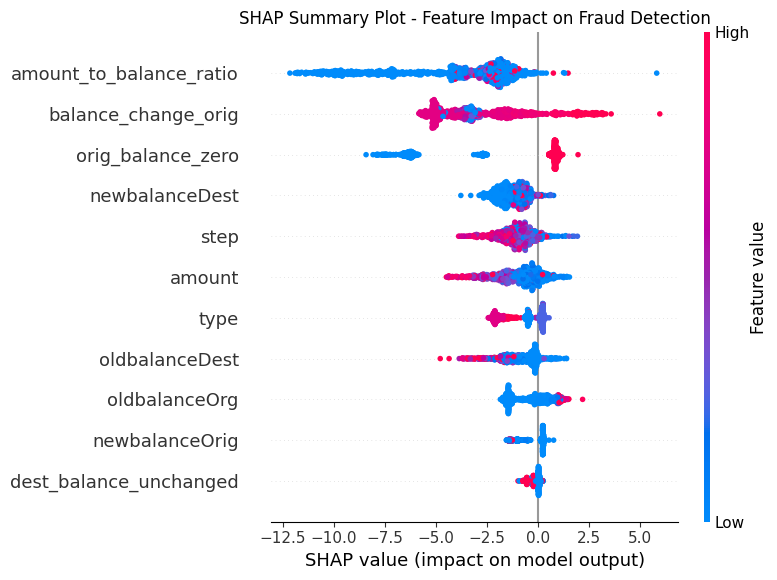

SHAP summary plot saved


In [5]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Summary Plot - Feature Impact on Fraud Detection")
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', bbox_inches='tight')
plt.show()
print("SHAP summary plot saved")

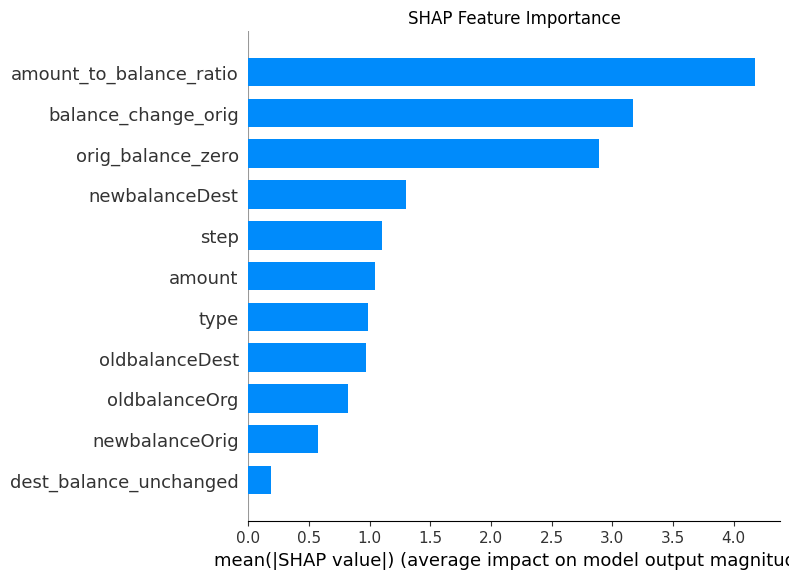

SHAP bar plot saved


In [6]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.savefig('../reports/shap_bar.png', bbox_inches='tight')
plt.show()
print("SHAP bar plot saved")

In [7]:
# Find a real fraud case in our sample
fraud_indices = y_sample[y_sample == 1].index
fraud_idx     = fraud_indices[0]
fraud_pos     = X_sample.index.get_loc(fraud_idx)

print(f"Explaining fraud transaction at index: {fraud_idx}")
print()
print("Transaction details:")
print(X_sample.loc[fraud_idx])

Explaining fraud transaction at index: 6020257

Transaction details:
step                           461.00
type                             1.00
amount                     6273660.45
oldbalanceOrg              6273660.45
newbalanceOrig                   0.00
oldbalanceDest              763912.31
newbalanceDest             7037572.76
balance_change_orig        6273660.45
orig_balance_zero                1.00
dest_balance_unchanged           0.00
amount_to_balance_ratio          1.00
Name: 6020257, dtype: float64


In [8]:
# Get SHAP values for this specific transaction
fraud_shap = shap_values[fraud_pos]

# Create a clean dataframe showing feature contributions
shap_df = pd.DataFrame({
    'feature':    X_sample.columns,
    'value':      X_sample.loc[fraud_idx].values,
    'shap_value': fraud_shap
}).sort_values('shap_value', ascending=False)

print("SHAP values for this fraud transaction:")
print(shap_df.to_string(index=False))

SHAP values for this fraud transaction:
                feature      value  shap_value
    balance_change_orig 6273660.45    5.958772
amount_to_balance_ratio       1.00    5.807093
          oldbalanceOrg 6273660.45    2.179593
      orig_balance_zero       1.00    1.955836
                   step     461.00    0.422065
         newbalanceOrig       0.00    0.366934
                 amount 6273660.45    0.221189
                   type       1.00    0.171167
 dest_balance_unchanged       0.00    0.095119
         newbalanceDest 7037572.76   -0.457796
         oldbalanceDest  763912.31   -0.721644


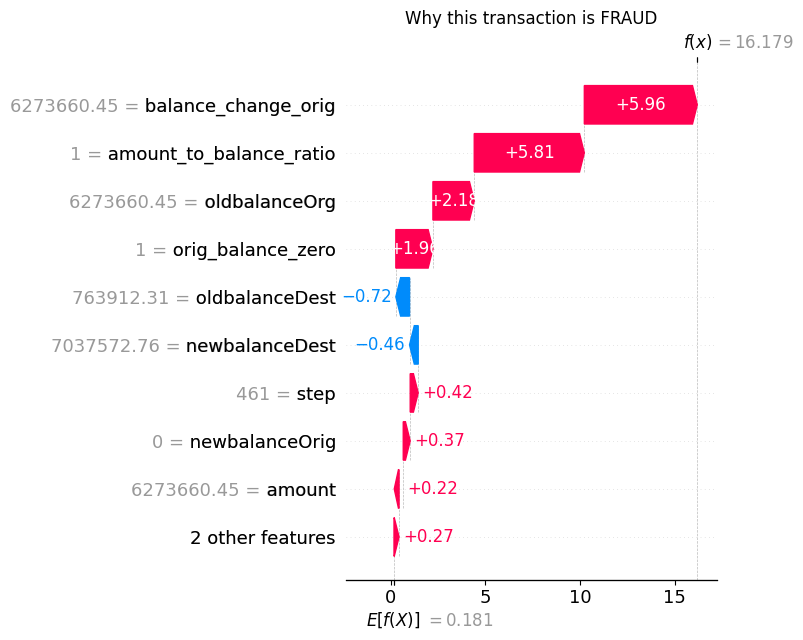

Waterfall plot saved


In [9]:
shap_explanation = shap.Explanation(
    values         = fraud_shap,
    base_values    = explainer.expected_value,
    data           = X_sample.loc[fraud_idx].values,
    feature_names  = X_sample.columns.tolist()
)

plt.figure()
shap.plots.waterfall(shap_explanation, show=False)
plt.title("Why this transaction is FRAUD")
plt.tight_layout()
plt.savefig('../reports/shap_waterfall_fraud.png', bbox_inches='tight')
plt.show()
print("Waterfall plot saved")

In [10]:
def get_shap_explanation_input(transaction_index):
    """
    Given a transaction index from X_test,
    returns a clean dictionary of top SHAP features
    ready to send to GPT-4o
    """
    pos       = X_sample.index.get_loc(transaction_index)
    shap_vals = shap_values[pos]
    
    shap_df = pd.DataFrame({
        'feature':    X_sample.columns,
        'value':      X_sample.loc[transaction_index].values,
        'shap_value': shap_vals
    }).sort_values('shap_value', key=abs, ascending=False)
    
    top_features = shap_df.head(5)
    
    result = {
        'transaction_index': transaction_index,
        'is_fraud':          int(y_sample.loc[transaction_index]),
        'fraud_probability':  float(model.predict_proba(
                                X_sample.loc[[transaction_index]]
                              )[0][1]),
        'top_shap_features': top_features.to_dict('records')
    }
    
    return result

# Test it on our fraud case
explanation_input = get_shap_explanation_input(fraud_idx)
print("GPT-4o input prepared:")
print(f"Is Fraud:          {explanation_input['is_fraud']}")
print(f"Fraud Probability: {explanation_input['fraud_probability']:.4f}")
print(f"\nTop 5 features driving this prediction:")
for f in explanation_input['top_shap_features']:
    print(f"  {f['feature']:<30} value={f['value']:.2f}  shap={f['shap_value']:.4f}")

GPT-4o input prepared:
Is Fraud:          1
Fraud Probability: 1.0000

Top 5 features driving this prediction:
  balance_change_orig            value=6273660.45  shap=5.9588
  amount_to_balance_ratio        value=1.00  shap=5.8071
  oldbalanceOrg                  value=6273660.45  shap=2.1796
  orig_balance_zero              value=1.00  shap=1.9558
  oldbalanceDest                 value=763912.31  shap=-0.7216


In [11]:
joblib.dump(explainer, '../models/shap_explainer.pkl')
joblib.dump(X_sample,  '../models/X_sample.pkl')
joblib.dump(y_sample,  '../models/y_sample.pkl')

print("Explainer and sample saved to models/ folder")

Explainer and sample saved to models/ folder


In [12]:
print("=" * 50)
print("SHAP ANALYSIS COMPLETE")
print("=" * 50)
print(f"Sample size:         {X_sample.shape[0]}")
print(f"Fraud in sample:     {y_sample.sum()}")
print(f"Top fraud indicator: {shap_df.iloc[0]['feature']}")
print()
print("Files saved in reports/:")
print("  shap_summary.png")
print("  shap_bar.png")
print("  shap_waterfall_fraud.png")
print()
print("Ready for Notebook 05 - GPT-4o Explanation")
print("=" * 50)

SHAP ANALYSIS COMPLETE
Sample size:         1000
Fraud in sample:     1
Top fraud indicator: balance_change_orig

Files saved in reports/:
  shap_summary.png
  shap_bar.png
  shap_waterfall_fraud.png

Ready for Notebook 05 - GPT-4o Explanation
